# EDA

importing data:

In [9]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Define the main data directory
base_dir = "cFMD_data"

# Lists that will store all smaller DataFrames before merging
all_metadata_dfs = []
all_tax_profile_dfs = []

# Iterate over all items in the base directory
for dataset_name in os.listdir(base_dir):
    dataset_path = os.path.join(base_dir, dataset_name)
    
    # Make sure the item is a directory and not an unrelated file such as .DS_Store
    if os.path.isdir(dataset_path):
        metadata_file = os.path.join(dataset_path, f"{dataset_name}_metadata.tsv")
        tax_file = os.path.join(dataset_path, f"{dataset_name}_taxonomic_profiles.tsv")
        
        # Check that both required files exist before reading them
        if os.path.exists(metadata_file) and os.path.exists(tax_file):
            print(f"Reading dataset: {dataset_name}...")
            
            # Read the metadata file
            df_meta = pd.read_csv(metadata_file, sep="\t")
            all_metadata_dfs.append(df_meta)
            
            # Read the taxonomic profile file and set the bacteria column as the index
            df_tax = pd.read_csv(tax_file, sep="\t", index_col=0)
            all_tax_profile_dfs.append(df_tax)
        else:
            print(f"Warning: missing files in folder {dataset_name}")

# --- Main merging step ---

print("\nMerging master tables...")

# 1. Merge metadata tables by stacking rows
if all_metadata_dfs:
    df_master_metadata = pd.concat(all_metadata_dfs, ignore_index=True)
    print(f"Unified metadata table is ready! Shape: {df_master_metadata.shape}")
else:
    df_master_metadata = pd.DataFrame()

# 2. Merge taxonomic profile tables by adding columns according to the bacteria index
if all_tax_profile_dfs:
    # axis=1 means adding columns. join='outer' keeps all bacteria from all datasets
    df_master_tax_profile = pd.concat(all_tax_profile_dfs, axis=1, join='outer')
    
    # Missing bacteria across datasets create NaN values. Replace them with 0, meaning zero abundance
    df_master_tax_profile = df_master_tax_profile.fillna(0)
    
    print(f"Unified taxonomic profile table is ready! Shape: {df_master_tax_profile.shape}")
else:
    df_master_tax_profile = pd.DataFrame()

# Display a preview of the results
display(df_master_metadata.head())
display(df_master_tax_profile.head())

Reading dataset: AlmeidaO_2020...
Reading dataset: AlvarezOrdonezA_xxxx...
Reading dataset: ArikanM_2020...
Reading dataset: BertuzziAS_2018...
Reading dataset: ChaconVargasK_2020...
Reading dataset: CM_INJERA...
Reading dataset: CM_UNINA_FFOOD...
Reading dataset: CrovadoreJ_2017...
Reading dataset: DecadtH_2024...
Reading dataset: DeFilippisF_xxxx...
Reading dataset: DeRoosJ_2020...
Reading dataset: DuruIC_2018...
Reading dataset: DuR_2020...
Reading dataset: EinsonEJ_2018...
Reading dataset: EscobarZepedaA_2016...
Reading dataset: FalardeauJ_2023...
Reading dataset: FerrocinoI_2018...
Reading dataset: FontanaF_2023...
Reading dataset: FranciosaI_2021...
Reading dataset: GonzalezOrozcoB_2023...
Reading dataset: HeilCS_2018...
Reading dataset: HellmannSL_2020...
Reading dataset: KastmanEK_2016...
Reading dataset: KharnaiorP_2023...
Reading dataset: KumarJ_2019...
Reading dataset: LandisEA_2021...
Reading dataset: LeechJ_2020...
Reading dataset: LeechJ_xxxx...
Reading dataset: LeonardSR

,dataset_name,sample_id,macrocategory,category,type,subtype,commercial_name,fermented/non-fermented,country,sample_accession,...,median_read_len,mean_read_len,max_read_len,n_contigs,n_MAGs_MQ_prok,n_MAGs_HQ_prok,n_MAGs_MQ_euk,n_MAGs_HQ_euk,filtered,curator
0,AlmeidaO_2020,SRR8742576,food,fermented_seeds,cocoa_beans,NaN,NaN,F,BRA,SAMN11159366,...,76.0,75.573094,76.0,7737.0,1.0,2.0,1.0,0.0,no,Liam_Walsh
1,AlmeidaO_2020,SRR8742577,food,fermented_seeds,cocoa_beans,NaN,NaN,F,BRA,SAMN11159365,...,76.0,75.578485,76.0,3608.0,1.0,0.0,1.0,0.0,no,Liam_Walsh
2,AlmeidaO_2020,SRR8742578,food,fermented_seeds,cocoa_beans,NaN,NaN,F,BRA,SAMN11159364,...,76.0,75.564474,76.0,6514.0,2.0,0.0,1.0,0.0,no,Liam_Walsh
3,AlmeidaO_2020,SRR8742579,food,fermented_seeds,cocoa_beans,NaN,NaN,F,BRA,SAMN11159363,...,76.0,75.542780,76.0,60.0,0.0,0.0,0.0,0.0,yes,Liam_Walsh
4,AlmeidaO_2020,SRR8742580,food,fermented_seeds,cocoa_beans,NaN,NaN,F,BRA,SAMN11159370,...,76.0,75.509721,76.0,2465.0,1.0,1.0,0.0,0.0,no,Liam_Walsh


,AlmeidaO_2020__SRR8742576,AlmeidaO_2020__SRR8742577,AlmeidaO_2020__SRR8742578,AlmeidaO_2020__SRR8742579,AlmeidaO_2020__SRR8742580,AlmeidaO_2020__SRR8742581,AlmeidaO_2020__SRR8742582,AlmeidaO_2020__SRR8742584,AlmeidaO_2020__SRR8742585,AlvarezOrdonezA_xxxx__C01-19,...,YuY_2022__SRR16950700,YuY_2022__SRR16950701,YuY_2022__SRR16950702,YuY_2022__SRR16950703,YuY_2022__SRR16950704,ZhaoCC_2020__SRS5803191,ZhaoCC_2020__SRS5803192,ZhaoCC_2020__SRS5803193,ZhaoCC_2020__SRS5803194,ZhaoCC_2020__SRS5803195
sample,,,,,,,,,,,,,,,,,,,,,
k__Bacteria|p__Firmicutes|c__Bacilli|o__Lactobacillales|f__Streptococcaceae|g__Lactococcus|s__Lactococcus_lactis|t__SGB7985,0.14109,0.0,0.40403,0.00000,0.00000,0.00000,0.00000,0.0,0.00000,0.0,...,9.44002,9.00307,0.02590,0.02644,0.01921,0.0,0.0,0.0,0.0,0.0
k__Bacteria|p__Actinomycetota|c__Actinomycetes|o__Propionibacteriales|f__Propionibacteriaceae|g__Cutibacterium|s__Cutibacterium_acnes|t__SGB16955,0.00000,0.0,0.00000,0.62919,0.00000,0.00000,0.00000,0.0,0.00000,0.0,...,0.00000,0.00000,0.00084,0.00000,0.00000,0.0,0.0,0.0,0.0,0.0
k__Bacteria|p__Firmicutes|c__Bacilli|o__Lactobacillales|f__Lactobacillaceae|g__Lactiplantibacillus|s__Lactiplantibacillus_plantarum|t__SGB7202,0.00000,0.0,0.00000,0.00000,0.24468,0.00653,0.08219,0.0,0.00553,0.0,...,51.21205,52.55470,0.12650,0.13905,0.12204,0.0,0.0,0.0,0.0,0.0
k__Bacteria|p__Pseudomonadota|c__Gammaproteobacteria|o__Enterobacterales|f__Erwiniaceae|g__Pantoea|s__Pantoea_coffeiphila|t__SGB23192,0.10390,0.0,0.08975,0.00000,0.00000,0.00000,0.00000,0.0,0.00000,0.0,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.0,0.0,0.0,0.0,0.0
k__Bacteria|p__Firmicutes|c__Bacilli|o__Bacillales|f__Paenibacillaceae|g__Paenibacillus|s__Paenibacillus_cookii|t__SGB7404,0.00000,0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.0,0.00236,0.0,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.0,0.0,0.0,0.0,0.0


### About the Data

This comprehensive dataset maps the microbial landscape of various foods, aggregated from 85 distinct scientific experiments. In total, the collection encompasses 4,344 unique food samples and profiles the abundance of approximately 14,000 different bacterial taxa. 

The data is organized into two primary, interconnected tables that separate the contextual information from the biological measurements:

* **The Metadata Table:** This table provides the descriptive, geographical, and technical context for every sample. Key columns include hierarchical food classifications (such as `macrocategory`, `category`, `type`, `subtype`, and `commercial_name`), the sample's geographical origin (`country`), and whether the food is fermented. It also contains essential technical metrics from the sequencing process, such as read lengths and base counts.
* **The Taxonomic Profile Table:** This table holds the actual microbiome composition data. It details the specific bacterial taxa—represented by complete taxonomic lineages from kingdom down to the species or strain level—and records their precise abundance or presence within the samples.

**Data Integration:** These two tables are intrinsically linked using a unique composite identifier. By combining the `dataset_name` with the specific `sample_id` from the metadata, we create a primary key that matches the sample columns/rows in the taxonomic profile. This seamless relationship allows us to correlate the physical and categorical attributes of any given food item directly with its complex microbial ecosystem.

### Let's check for null values existance:

Analyzing null values existence...


C:\Users\yontn\AppData\Local\Temp\ipykernel_13656\901195257.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_missing.values, y=top_missing.index, ax=ax, palette='magma')


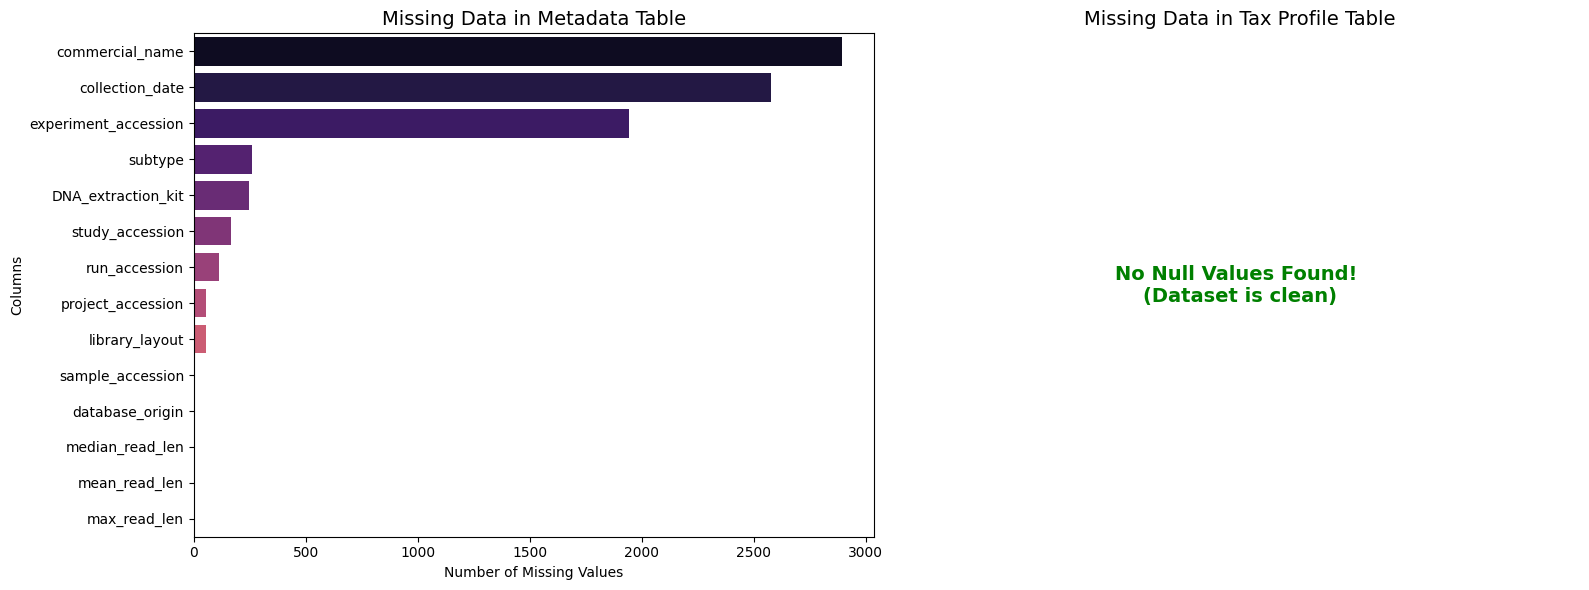

In [10]:
def plot_missing_values(df, title, ax):
    
    # Count null values for each column and keep only columns with missing values
    missing_data = df.isnull().sum()
    missing_data = missing_data[missing_data > 0].sort_values(ascending=False)
    
    if missing_data.empty:
        # If there are no missing values, display a message
        ax.text(0.5, 0.5, 'No Null Values Found! \n(Dataset is clean)', 
                ha='center', va='center', fontsize=14, color='green', fontweight='bold')
        ax.set_title(title, fontsize=14)
        ax.axis('off') # Hide the axes because there is no data to display
    else:
        # If there are missing values, create a bar plot
        # Show the top 20 columns with the most missing values to avoid overcrowding
        top_missing = missing_data.head(20) 
        sns.barplot(x=top_missing.values, y=top_missing.index, ax=ax, palette='magma')
        ax.set_title(title, fontsize=14)
        ax.set_xlabel('Number of Missing Values')
        ax.set_ylabel('Columns')

# Set up the visualization area with two plots side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

print("Analyzing null values existence...")

# Apply the function to both master tables
plot_missing_values(df_master_metadata, "Missing Data in Metadata Table", axes[0])
plot_missing_values(df_master_tax_profile, "Missing Data in Tax Profile Table", axes[1])

# Adjust spacing automatically and display the plots
plt.tight_layout()
plt.show()

The missing values analysis shows that the unified taxonomic profile table contains no null values, which confirms that the taxonomic abundance matrix is complete after replacing missing entries with zero during the merging step. In contrast, the metadata table contains several columns with missing values, mainly commercial_name, collection_date, and experiment_accession, followed by smaller amounts of missingness in fields such as subtype, DNA_extraction_kit, and accession-related columns. This indicates that while the bacterial abundance data is ready for analysis, some metadata fields are incomplete and should be treated carefully in later analyses, especially if they are used for grouping, filtering, or interpretation.

extracting features lists:

In [11]:
# 1. Extract the list of columns from the metadata table
metadata_columns = df_master_metadata.columns.tolist()

# 2. Extract the list of rows, meaning the bacteria/taxonomy names, from the taxonomic profile table
tax_profile_rows = df_master_tax_profile.index.tolist()

# Save the metadata columns
with open('metadata_columns_list.txt', 'w', encoding='utf-8') as f:
    for col in metadata_columns:
        f.write(f"{col}\n")

# Save the taxonomic profile rows
with open('tax_profile_rows_list.txt', 'w', encoding='utf-8') as f:
    for row in tax_profile_rows:
        f.write(f"{row}\n")

print(f"Exported {len(metadata_columns)} columns to 'metadata_columns_list.txt'")
print(f"Exported {len(tax_profile_rows)} rows to 'tax_profile_rows_list.txt'")

Exported 32 columns to 'metadata_columns_list.txt'
Exported 5057 rows to 'tax_profile_rows_list.txt'


In this step, we exported two structural summaries of the unified data tables. The first file contains the list of metadata columns, which helps document the available sample-level information. The second file contains the list of taxonomic profile rows, representing the bacterial taxa included in the abundance matrix. Saving these lists as text files makes it easier to inspect the dataset structure separately and decide which metadata fields and bacterial taxa may be useful for the next stages of the exploratory analysis.

### let's check for Exact Profile Duplicates (2 foods with the same microbiom profile is impossible):

In [ ]:
df_tax = df_master_tax_profile.copy()

print("Starting a deep duplicate scan in the microbiome table...\n")

# Make sure samples are rows so pandas can compare them easily
if df_tax.shape[0] < df_tax.shape[1] or any('Bacteria' in str(idx) for idx in df_tax.index[:5]):
    df_tax_t = df_tax.T # Transpose the table so samples become rows
else:
    df_tax_t = df_tax.copy()

# 1. Search for exact duplicates: 100% identical profiles, even if the sample names are different
exact_duplicates = df_tax_t[df_tax_t.duplicated(keep=False)]

if not exact_duplicates.empty:
    print(f"Found {len(exact_duplicates)} samples with completely identical bacterial profiles, possibly copied by mistake:")
    
    # Safe and efficient grouping by converting each row to a tuple, avoiding pandas confusion with thousands of columns
    grouped_dups = exact_duplicates.groupby(exact_duplicates.apply(tuple, axis=1)).apply(lambda x: x.index.tolist())
    
    for group in grouped_dups.values:
        print(f"  - The following samples are completely identical to each other: {group}")
else:
    print("No samples with completely identical bacterial profiles were found (100% match).")

Starting a deep duplicate scan in the microbiome table...

Found 26 samples with completely identical bacterial profiles, possibly copied by mistake:
  - The following samples are completely identical to each other: ['WalshL_xxxx__T11', 'WalshL_xxxx__U5']
  - The following samples are completely identical to each other: ['McHughAJ_2020__ERS3128649', 'McHughAJ_2020__ERS3128650']
  - The following samples are completely identical to each other: ['HellmannSL_2020__ERS3651756', 'HellmannSL_2020__ERS3651758', 'HellmannSL_2020__ERS3651759', 'HellmannSL_2020__ERS3651760', 'HellmannSL_2020__ERS3651761']
  - The following samples are completely identical to each other: ['PatroJN_2016__SRS1044734', 'PatroJN_2016__SRS1044740']
  - The following samples are completely identical to each other: ['AlvarezOrdonezA_xxxx__F07-16', 'AlvarezOrdonezA_xxxx__F07-31A']
  - The following samples are completely identical to each other: ['McHughAJ_2020__ERS3128654', 'McHughAJ_2020__ERS3128655']
  - The following

Exact duplicate microbiome profiles may indicate repeated measurements of the same food item or possible data entry issues. Identifying these duplicates is important before further analysis, because duplicated samples can affect clustering, similarity measures, and prediction models.


## In addition, if we will create a prediction model, we must delete those duplicates. !!!

### Food Item Duplication and Consistency Analysis

When evaluating the food attributes in our metadata (specifically within columns such as `subtype`, `category`, or `commercial_name`), it is crucial to distinguish between two distinct types of "duplicates":

* **Valid Duplicates (Multiple Samples per Food Item):**
  This metric tracks how many times a specific food item (e.g., a particular cheese type in the `subtype` column or a specific brand in the `commercial_name` column) was actually sampled. Having multiple biological or technical samples of the same food is excellent for research validity and statistical power. However, it is essential to map out this distribution to identify any class imbalances in the dataset.

* **"Dirty" Duplicates (Data Entry Inconsistencies & Typos):**
  This occurs when the exact same food item is recorded under slightly different text formats across different rows. For example, entries might appear inconsistently as `"Cheddar"`, `"cheddar"`, `"Cheddar "` (with a trailing space), or `"Cheddar Cheese"`. Resolving these inconsistencies is a critical preprocessing step; if left uncleaned, a machine learning model will incorrectly interpret them as entirely distinct food features, which can severely degrade its predictive accuracy and pattern recognition.

--- Duplicate analysis for column: 'subtype' ---

There are 149 food types that appear more than once in the dataset.
Top 10 most frequent food types:


,Count
subtype,
milk_kefir,285
water_kefir_figs_fresh_liquid,192
raw_milk_cheese,128
Cheddar,102
water_kefir_figs_dried_liquid,100
Cheese_1_before_ripening,97
cheese_2_before_ripening,96
cheese_2_after_ripening,95
Cheese_1_after_ripening,94


C:\Users\yontn\AppData\Local\Temp\ipykernel_13656\1225719262.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=repeated_foods.head(15).values, y=repeated_foods.head(15).index, palette='mako')


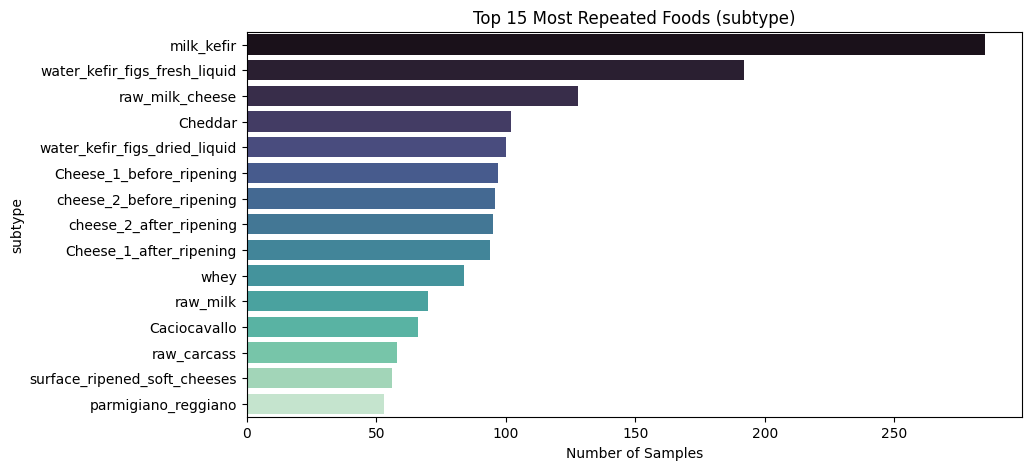


--- Searching for dirty text duplicates, meaning the same food written in different ways ---
Found 25 food items with inconsistent spelling.
Examples of inconsistencies that should be reviewed and possibly standardized:
  * The food item 'abondance' appears as: ['abondance', 'Abondance']
  * The food item 'asiago' appears as: ['asiago', 'Asiago']
  * The food item 'blue_cheese' appears as: ['blue_cheese', 'Blue_cheese']
  * The food item 'brie' appears as: ['Brie', 'brie']
  * The food item 'caciocavallo' appears as: ['caciocavallo', 'Caciocavallo']
  * The food item 'caciotta' appears as: ['Caciotta', 'caciotta']
  * The food item 'camembert' appears as: ['camembert', 'Camembert']
  * The food item 'cheddar' appears as: ['Cheddar', 'cheddar']
  * The food item 'comte' appears as: ['comte', 'Comte']
  * The food item 'edam' appears as: ['edam', 'Edam']


In [ ]:

# Make sure the metadata table is available
df_meta = df_master_metadata.copy()

# Select the column that represents the specific food item.
# This can be changed to 'commercial_name' or 'category' depending on the desired resolution
food_column = 'subtype' 

print(f"--- Duplicate analysis for column: '{food_column}' ---")

# Remove missing values
foods_series = df_meta[food_column].dropna().astype(str)

# 1. Which food items appear most often? Multiple samples
food_counts = foods_series.value_counts()
repeated_foods = food_counts[food_counts > 1]

print(f"\nThere are {len(repeated_foods)} food types that appear more than once in the dataset.")
if not repeated_foods.empty:
    print("Top 10 most frequent food types:")
    display(pd.DataFrame({'Count': repeated_foods.head(10)}))

# Create a quick plot of the most repeated food items
plt.figure(figsize=(10, 5))
sns.barplot(x=repeated_foods.head(15).values, y=repeated_foods.head(15).index, palette='mako')
plt.title(f'Top 15 Most Repeated Foods ({food_column})')
plt.xlabel('Number of Samples')
plt.show()

# ---------------------------------------------------------
# 2. Detect dirty duplicates: typos, case sensitivity, and extra spaces
# ---------------------------------------------------------
print("\n--- Searching for dirty text duplicates, meaning the same food written in different ways ---")

# Create a cleaned version of the text: lowercase letters and no extra spaces at the beginning or end
clean_foods = foods_series.str.lower().str.strip()

# Check which original values were mapped to the same cleaned value
# This can reveal cases such as "Cheddar" and "cheddar"
mapping_df = pd.DataFrame({
    'Original': foods_series,
    'Cleaned': clean_foods
})

# Group by the cleaned value and check how many different original values it has
dirty_duplicates = mapping_df.groupby('Cleaned')['Original'].unique()

# Keep only values that have more than one original spelling version
inconsistent_spellings = dirty_duplicates[dirty_duplicates.apply(len) > 1]

if not inconsistent_spellings.empty:
    print(f"Found {len(inconsistent_spellings)} food items with inconsistent spelling.")
    print("Examples of inconsistencies that should be reviewed and possibly standardized:")
    for clean_name, original_versions in inconsistent_spellings.head(10).items():
        print(f"  * The food item '{clean_name}' appears as: {list(original_versions)}")
else:
    print("No capitalization or extra-space spelling inconsistencies were found. The records are consistent.")

## We will use those duplicates, only if they have different biomicrobium profile - it means that maybe it is the same food but those are different measurements.

### Food Category Distribution and Typological Diversity

To fully understand the composition of our dataset, it is important to analyze the macroscopic classifications of the samples:

* **Category Distribution:** The pie chart below illustrates the relative proportions of different food categories within our dataset. This visual representation helps identify the dominant food groups and potential class imbalances.
* **Typological Diversity:** By analyzing the `type` attribute, we can quantify the exact number of distinct food varieties sampled. This metric provides insight into the breadth, scope, and diversity of the culinary items included in the study.

--------------------------------------------------
Total number of unique food types ('type' column): 116
--------------------------------------------------


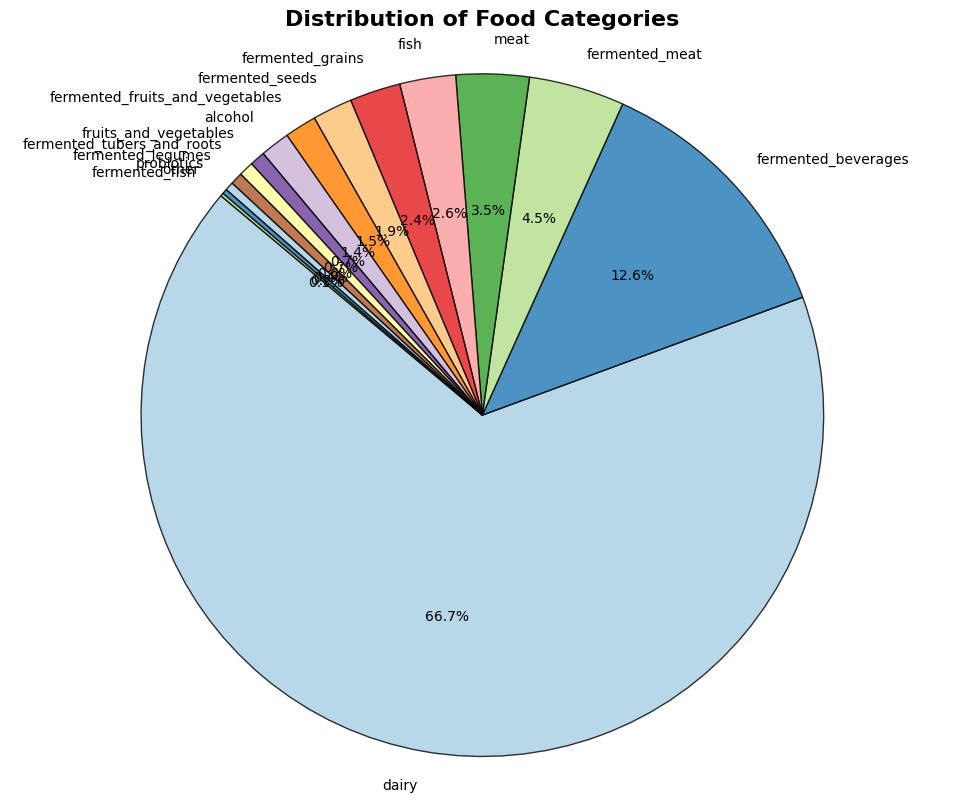

In [ ]:


# 1. Count Unique Food Types
# Drop NaN values before counting to avoid counting 'missing' as a type
unique_types_count = df_meta['type'].dropna().nunique()

print("-" * 50)
print(f"Total number of unique food types ('type' column): {unique_types_count}")
print("-" * 50)

# 2. Generate Pie Chart for Food Categories
# Count the occurrences of each category
category_counts = df_meta['category'].value_counts()

# Set up the plot
plt.figure(figsize=(10, 8))

# Create the pie chart
# autopct='%1.1f%%' adds the percentage labels to the wedges
plt.pie(
    category_counts.values, 
    labels=category_counts.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=plt.cm.Paired.colors,
    wedgeprops={'edgecolor': 'black', 'linewidth': 1, 'alpha': 0.8}
)

# Add title and ensure it's a perfect circle
plt.title('Distribution of Food Categories', fontsize=16, fontweight='bold', pad=20)
plt.axis('equal') 

plt.tight_layout()
plt.show()

### Geographical Distribution of Samples

Understanding the geographical origin of the food samples is essential for tracking regional microbial variations and assessing the global diversity of the dataset:

* **Global Reach:** The total number of unique countries from which the samples originate, indicating the geographical breadth of the study.
* **Country Distribution:** The bar chart below visualizes the primary contributing countries, highlighting where the majority of our data originates and helping to identify any geographical biases.

--------------------------------------------------
Total number of unique countries ('country' column): 53
--------------------------------------------------


C:\Users\yontn\AppData\Local\Temp\ipykernel_13656\3916239985.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')


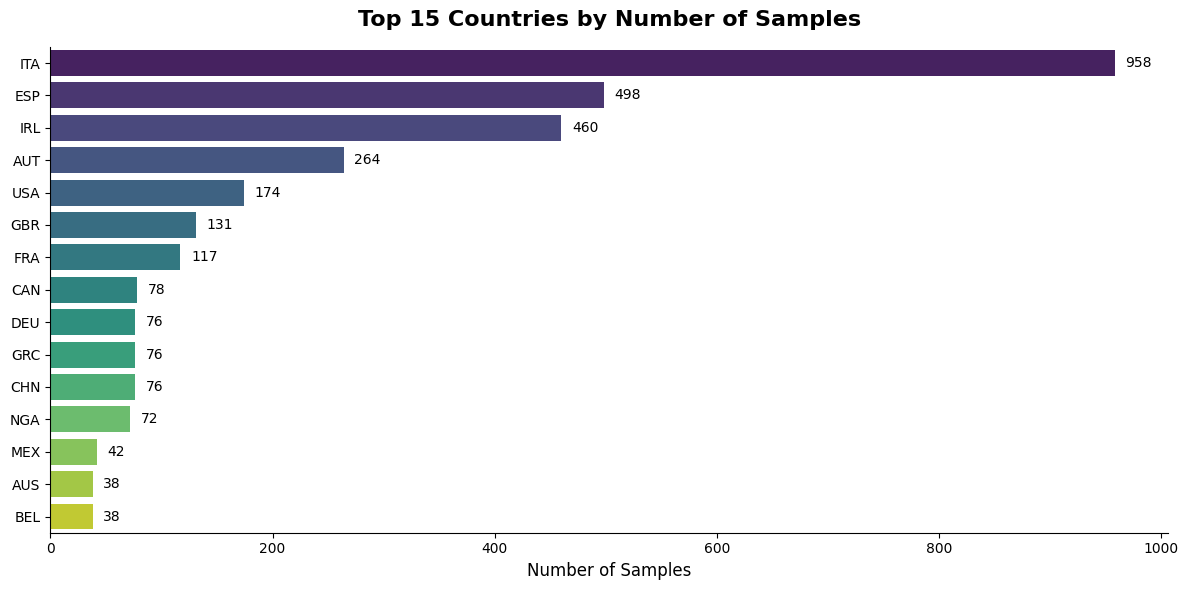

* Note: The chart displays the top 15 out of 53 total countries.


In [ ]:

# 1. Count Unique Countries
# Drop NaN values to avoid counting missing data as a country
unique_countries_count = df_meta['country'].dropna().nunique()

print("-" * 50)
print(f"Total number of unique countries ('country' column): {unique_countries_count}")
print("-" * 50)

# 2. Generate Bar Chart for Top Countries
# Count the occurrences of each country
country_counts = df_meta['country'].value_counts()

# To keep the chart readable, we will plot the top 15 countries
top_n = 15
top_countries = country_counts.head(top_n)

plt.figure(figsize=(12, 6))

# Create a horizontal bar chart for better readability of long country names
ax = sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')

plt.title(f'Top {top_n} Countries by Number of Samples', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Number of Samples', fontsize=12)
plt.ylabel('', fontsize=12) # Hide the y-axis label since the country names are self-explanatory

# Add the exact count at the end of each bar
for i, v in enumerate(top_countries.values):
    ax.text(v + (max(top_countries.values) * 0.01), i, str(v), color='black', va='center', fontsize=10)

sns.despine()
plt.tight_layout()
plt.show()

# Print a small note if there are more countries not displayed in the chart
if len(country_counts) > top_n:
    print(f"* Note: The chart displays the top {top_n} out of {len(country_counts)} total countries.")

### Taxonomic Composition and Microbial Profiling

To make sense of the highly dimensional microbial data, we aggregate the complex taxonomic strings into higher-level biological classifications. This allows us to understand the general "bacterial families" dominating our food samples.

* **Macro-Level Distribution (Phylum):** The pie chart illustrates the average relative abundance of the major bacterial phyla (e.g., Firmicutes, Proteobacteria, Bacteroidota) across all samples. This represents the high-level microbial landscape of the dataset.
* **Micro-Level Prevalence (Genus):** The bar chart displays the top 15 most prevalent bacterial genera. Rather than looking at abundance, this metric counts in how many distinct food samples a specific genus (e.g., *Lactobacillus*, *Lactococcus*) appears, highlighting the most universal microbes in our food database.

Parsing taxonomic hierarchy...


C:\Users\yontn\AppData\Local\Temp\ipykernel_13656\1893729210.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genera.values, y=top_genera.index, ax=axes[1], palette='flare')


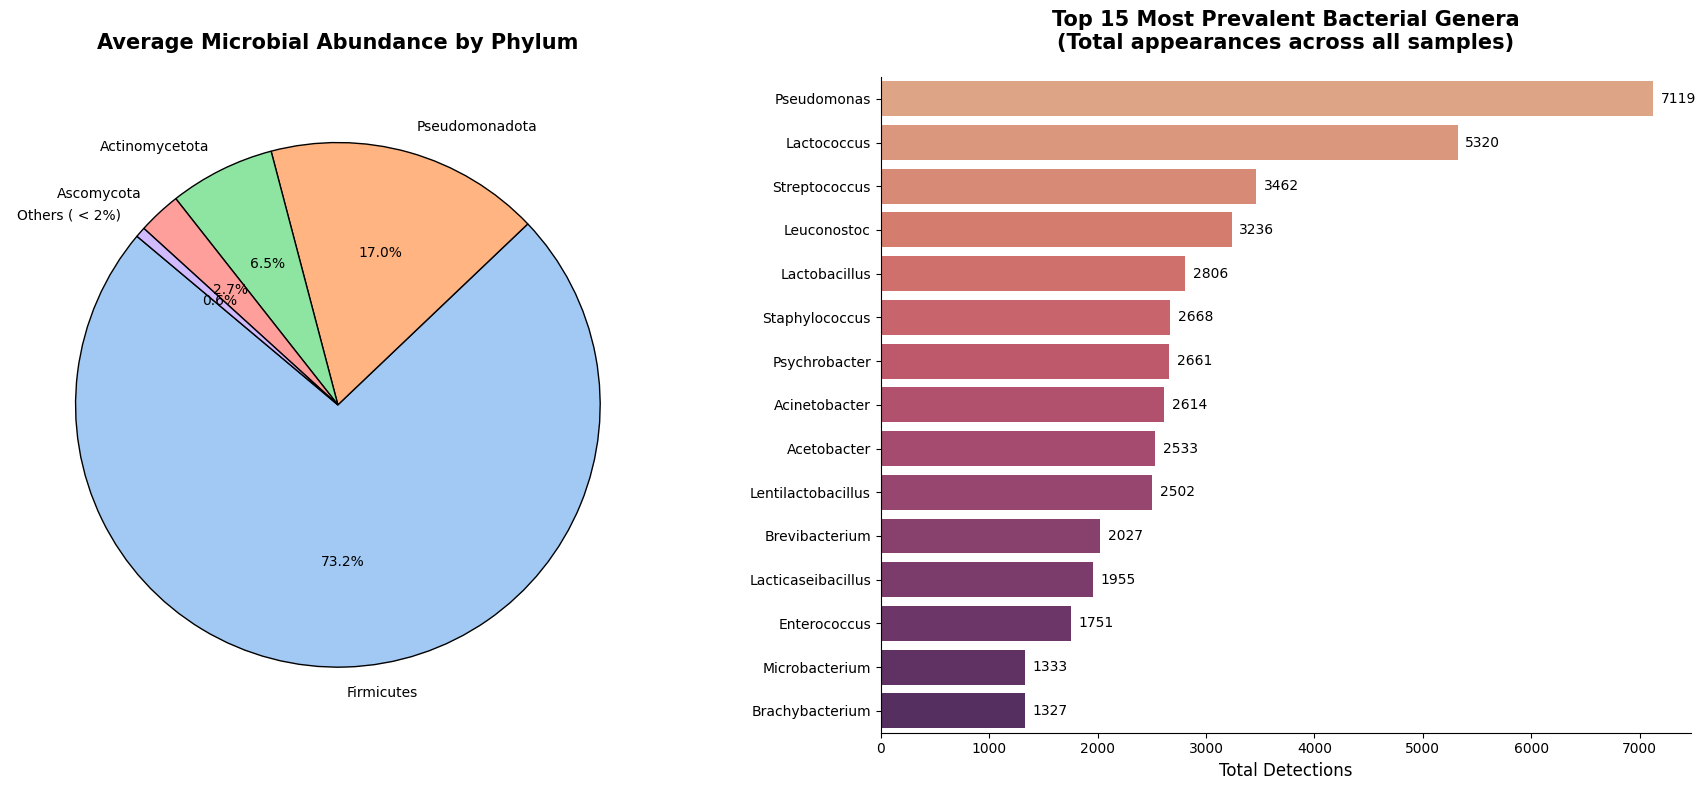

In [17]:

# 1. Detect orientation: get the taxa strings and the data
if df_tax.shape[0] > df_tax.shape[1] or any('Bacteria' in str(idx) for idx in df_tax.index[:5]):
    # Taxa are rows
    taxa_strings = pd.Series(df_tax.index)
    abundance_data = df_tax
else:
    # Taxa are columns
    taxa_strings = pd.Series(df_tax.columns)
    abundance_data = df_tax.T

print("Parsing taxonomic hierarchy...")

# 2. Extract Phylum (p__) and Genus (g__) using Regex
phylum_series = taxa_strings.str.extract(r'p__([^|]+)')[0].fillna('Unknown')
genus_series = taxa_strings.str.extract(r'g__([^|]+)')[0].fillna('Unknown')


# --- ERROR FIX: Force data to be strictly numeric before calculating ---
# This converts any accidental strings into NaN, and then replaces them with 0
abundance_numeric = abundance_data.apply(pd.to_numeric, errors='coerce').fillna(0)


# --- Plot 1: Phylum Distribution (Pie Chart based on Mean Abundance) ---

# Calculate the mean abundance for each specific taxon across all samples using the numeric data
mean_abundance_per_taxon = abundance_numeric.mean(axis=1).values

# Create a dataframe to group by Phylum
phylum_df = pd.DataFrame({
    'Phylum': phylum_series,
    'Mean_Abundance': mean_abundance_per_taxon
})

# Sum abundance by Phylum
phylum_abundance = phylum_df.groupby('Phylum')['Mean_Abundance'].sum().sort_values(ascending=False)

# Group small phyla into "Others" to keep the pie chart clean
threshold = phylum_abundance.sum() * 0.02 # 2% threshold
main_phyla = phylum_abundance[phylum_abundance >= threshold]
other_phyla = pd.Series({'Others ( < 2%)': phylum_abundance[phylum_abundance < threshold].sum()})
pie_data = pd.concat([main_phyla, other_phyla])

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Draw Pie Chart
axes[0].pie(
    pie_data.values, 
    labels=pie_data.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=sns.color_palette("pastel"),
    wedgeprops={'edgecolor': 'black', 'linewidth': 1}
)
axes[0].set_title('Average Microbial Abundance by Phylum', fontsize=15, fontweight='bold', pad=20)


# --- Plot 2: Top Genera Prevalence (Bar Chart based on presence > 0) ---

# Calculate in how many samples each taxon appears (using the numeric data)
prevalence_per_taxon = (abundance_numeric > 0).sum(axis=1).values

# Create a dataframe to group by Genus
genus_df = pd.DataFrame({
    'Genus': genus_series,
    'Prevalence': prevalence_per_taxon
})

# Sum prevalence by Genus
genus_prevalence = genus_df.groupby('Genus')['Prevalence'].sum().sort_values(ascending=False)

# Remove 'Unknown' if it's there, and take top 15
if 'Unknown' in genus_prevalence:
    genus_prevalence = genus_prevalence.drop('Unknown')
top_genera = genus_prevalence.head(15)

# Draw Bar Chart
sns.barplot(x=top_genera.values, y=top_genera.index, ax=axes[1], palette='flare')
axes[1].set_title('Top 15 Most Prevalent Bacterial Genera\n(Total appearances across all samples)', fontsize=15, fontweight='bold', pad=20)
axes[1].set_xlabel('Total Detections', fontsize=12)
axes[1].set_ylabel('')

# Add labels to the bars
for i, v in enumerate(top_genera.values):
    axes[1].text(v + (max(top_genera.values) * 0.01), i, str(int(v)), color='black', va='center')

sns.despine(ax=axes[1])
plt.tight_layout()
plt.show()

### Microbial Diversity and Dominance (Alpha Diversity)

To understand the internal microbial ecosystem of our food samples, we evaluate two critical diversity metrics across different food categories. These metrics help us differentiate between complex, diverse microbiomes and highly specialized (or targeted) environments.

* **Microbial Richness:** The total number of unique bacterial taxa detected (abundance > 0) within a single food sample. High richness indicates a complex and highly diverse microbial community.
* **Microbial Dominance:** The maximum abundance level of the single most prevalent bacterial taxon in a sample. High dominance suggests that the sample's microbiome is heavily skewed and controlled by one specific bacterium (a common characteristic in strictly controlled fermented foods).

Calculating alpha diversity metrics...
Successfully matched 3393 samples between Metadata and Tax Profile!


C:\Users\yontn\AppData\Local\Temp\ipykernel_13656\1904032880.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x=food_group_column, y='Richness', ax=axes[0], palette='viridis')
C:\Users\yontn\AppData\Local\Temp\ipykernel_13656\1904032880.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x=food_group_column, y='Dominance', ax=axes[1], palette='plasma')


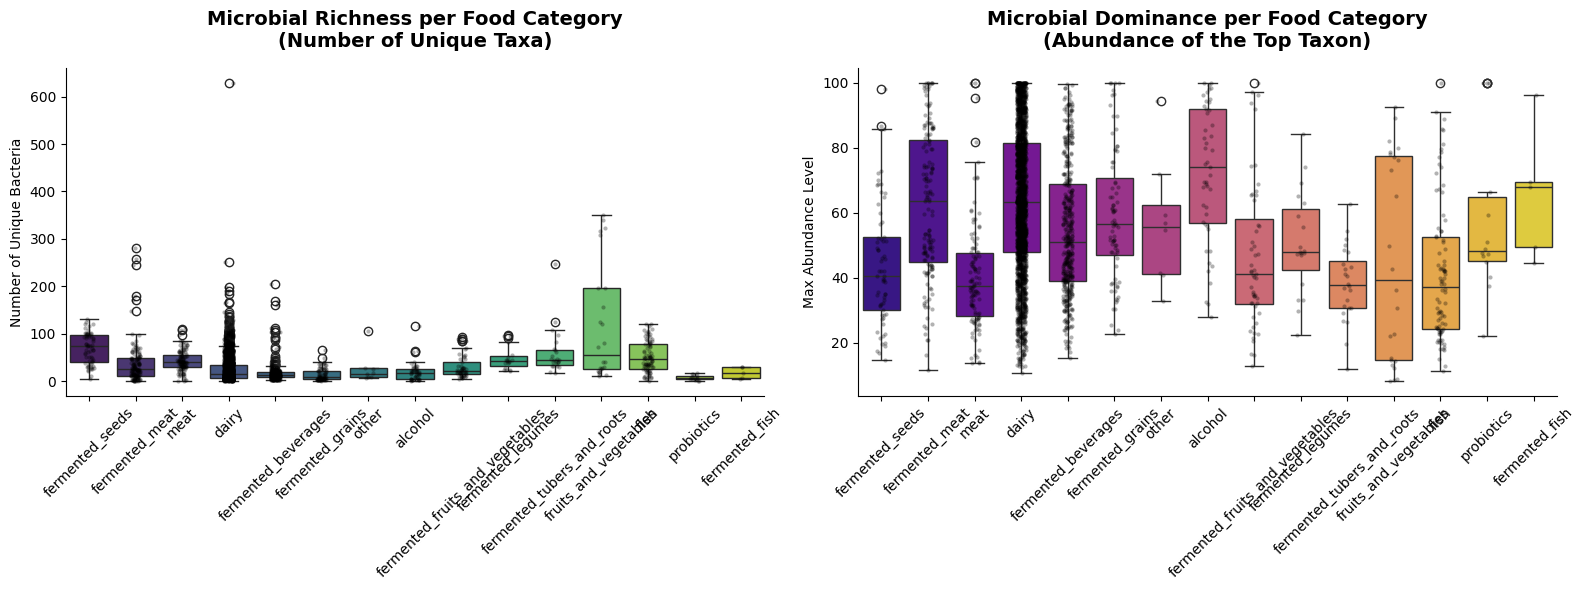

--------------------------------------------------
Average Metrics per Food Group ('category'):
--------------------------------------------------


,Richness,Dominance
category,,
alcohol,20.09,72.24
dairy,25.40,63.62
fermented_beverages,17.62,54.42
fermented_fish,18.40,65.48
fermented_fruits_and_vegetables,31.48,46.29
fermented_grains,14.51,59.13
fermented_legumes,49.26,50.68
fermented_meat,37.41,62.33
fermented_seeds,69.80,43.99


In [21]:
# Ensure the dataframes are available
df_meta = df_metadata if 'df_metadata' in locals() else df_master_metadata
df_tax = df_tax_profile if 'df_tax_profile' in locals() else df_master_tax_profile

print("Calculating alpha diversity metrics...")

# --- THE FIX: Ensure we have a matching ID column in metadata ---
# Recreate the 'combined_id' (e.g., LeechJ_2020__ERS3967688) so the tables can talk to each other
if 'combined_id' not in df_meta.columns:
    if 'dataset_name' in df_meta.columns and 'sample_id' in df_meta.columns:
        df_meta['combined_id'] = df_meta['dataset_name'] + '__' + df_meta['sample_id'].astype(str)

# 1. Detect orientation: Ensure rows are samples and columns are taxa
if df_tax.shape[0] > df_tax.shape[1] or any('Bacteria' in str(idx) for idx in df_tax.index[:5]):
    abundance_data = df_tax.T
else:
    abundance_data = df_tax

# Force data to be strictly numeric
abundance_numeric = abundance_data.apply(pd.to_numeric, errors='coerce').fillna(0)

# 2. Calculate Metrics per Sample
richness = (abundance_numeric > 0).sum(axis=1)
dominance = abundance_numeric.max(axis=1)

metrics_df = pd.DataFrame({
    'Richness': richness,
    'Dominance': dominance
})

# 3. Merge with Metadata to group by food category
food_group_column = 'category' # You can change this to 'subtype' or 'type'

# Set the correct index for merging
if 'combined_id' in df_meta.columns:
    df_meta_temp = df_meta.set_index('combined_id')
elif 'sample_id' in df_meta.columns:
    df_meta_temp = df_meta.set_index('sample_id')
else:
    df_meta_temp = df_meta.copy()

# Join the metrics with the selected food grouping column
plot_data = metrics_df.join(df_meta_temp[[food_group_column]], how='inner')

# Drop missing categories
plot_data = plot_data.dropna(subset=[food_group_column])

# --- Debug Print to ensure the merge worked ---
print(f"Successfully matched {len(plot_data)} samples between Metadata and Tax Profile!")
if len(plot_data) == 0:
    print("Warning: 0 samples matched. Please check if your Sample IDs match exactly.")

# 4. Generate Visualizations
if len(plot_data) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Plot 1: Richness Plot
    sns.boxplot(data=plot_data, x=food_group_column, y='Richness', ax=axes[0], palette='viridis')
    sns.stripplot(data=plot_data, x=food_group_column, y='Richness', ax=axes[0], color='black', alpha=0.3, size=3)
    axes[0].set_title('Microbial Richness per Food Category\n(Number of Unique Taxa)', fontsize=14, fontweight='bold', pad=15)
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].set_xlabel('')
    axes[0].set_ylabel('Number of Unique Bacteria')

    # Plot 2: Dominance Plot
    sns.boxplot(data=plot_data, x=food_group_column, y='Dominance', ax=axes[1], palette='plasma')
    sns.stripplot(data=plot_data, x=food_group_column, y='Dominance', ax=axes[1], color='black', alpha=0.3, size=3)
    axes[1].set_title('Microbial Dominance per Food Category\n(Abundance of the Top Taxon)', fontsize=14, fontweight='bold', pad=15)
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].set_xlabel('')
    axes[1].set_ylabel('Max Abundance Level')

    sns.despine()
    plt.tight_layout()
    plt.show()

    # 5. Print a numerical summary table
    print("-" * 50)
    print(f"Average Metrics per Food Group ('{food_group_column}'):")
    print("-" * 50)
    summary_stats = plot_data.groupby(food_group_column).mean().round(2)
    display(summary_stats)

### Extreme Values and Outlier Analysis (Alpha Diversity)

Beyond average metrics, identifying extreme values in microbial distribution provides critical insights into atypical samples within our dataset. 

* **High Extremes (Richness):** Samples with exceptionally high numbers of unique taxa may indicate highly complex natural fermentations, diverse environmental exposure, or potential contamination.
* **High Extremes (Dominance):** Samples where a single taxon approaches 100% abundance indicate a hyper-specialized environment, often seen in highly controlled monoculture fermentations or extreme microbial selection.
* **Diversity Landscape:** By plotting Richness against Dominance, we can visualize the typical ecological trade-off (highly diverse samples are rarely dominated by one microbe) and easily spot structural outliers that defy this trend.

Analyzing extreme values for alpha diversity...

EXTREME VALUES ANALYSIS (TOP & BOTTOM 5)

Top 5 HIGHEST Richness (Most diverse / potentially contaminated):


,Richness,Dominance,category,subtype,commercial_name
WalshL_xxxx__H3_S87,629,20.71084,dairy,milk_kefir_contamined,NaN
MASTER_WP4_UNINA_2__Q-18,350,22.20301,fruits_and_vegetables,post_processed_vegetables,NaN
MASTER_WP4_UNINA_2__J-16,339,8.80997,fruits_and_vegetables,pre_processed_vegetables,NaN
MASTER_WP4_UNINA_2__Q-19,323,22.83691,fruits_and_vegetables,post_processed_vegetables,NaN
MASTER_WP4_UNINA_2__J-17,316,14.29934,fruits_and_vegetables,pre_processed_vegetables,NaN



Top 5 LOWEST Richness (Least diverse / highly sterile):


,Richness,Dominance,category,subtype,commercial_name
AlvarezOrdonezA_xxxx__F07-16,1,100.0,meat,sausage_before_ripening,NaN
AlvarezOrdonezA_xxxx__F07-31A,1,100.0,meat,meat_batter,NaN
HellmannSL_2020__ERS3651755,1,100.0,fermented_meat,calibraton_sausage_containing_cattle_pig_chick...,NaN
HellmannSL_2020__ERS3651756,1,100.0,fermented_meat,calibraton_sausage_containing_cattle_pig_chick...,NaN
HellmannSL_2020__ERS3651758,1,100.0,fermented_meat,calibraton_sausage_containing_cattle_pig_chick...,NaN



Top 5 HIGHEST Dominance (Most heavily dominated by a single taxon):


,Richness,Dominance,category,subtype,commercial_name
AlvarezOrdonezA_xxxx__F07-16,1,100.0,meat,sausage_before_ripening,NaN
AlvarezOrdonezA_xxxx__F07-31A,1,100.0,meat,meat_batter,NaN
HellmannSL_2020__ERS3651755,1,100.0,fermented_meat,calibraton_sausage_containing_cattle_pig_chick...,NaN
HellmannSL_2020__ERS3651756,1,100.0,fermented_meat,calibraton_sausage_containing_cattle_pig_chick...,NaN
HellmannSL_2020__ERS3651758,1,100.0,fermented_meat,calibraton_sausage_containing_cattle_pig_chick...,NaN


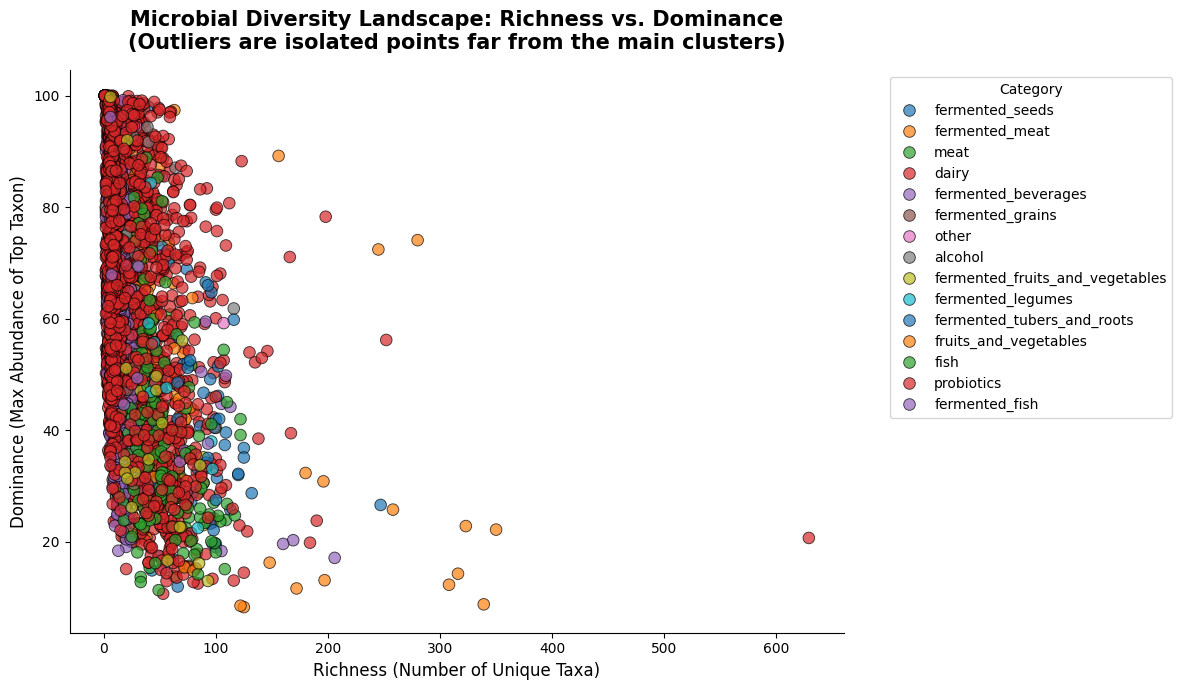

In [20]:
print("Analyzing extreme values for alpha diversity...\n")

# --- 1. Quick Data Prep (Ensuring standalone execution) ---
if 'combined_id' not in df_meta.columns:
    if 'dataset_name' in df_meta.columns and 'sample_id' in df_meta.columns:
        df_meta['combined_id'] = df_meta['dataset_name'] + '__' + df_meta['sample_id'].astype(str)

if df_tax.shape[0] > df_tax.shape[1] or any('Bacteria' in str(idx) for idx in df_tax.index[:5]):
    abundance_numeric = df_tax.T.apply(pd.to_numeric, errors='coerce').fillna(0)
else:
    abundance_numeric = df_tax.apply(pd.to_numeric, errors='coerce').fillna(0)

# Calculate metrics
richness = (abundance_numeric > 0).sum(axis=1)
dominance = abundance_numeric.max(axis=1)
metrics_df = pd.DataFrame({'Richness': richness, 'Dominance': dominance})

# Set index for merging
if 'combined_id' in df_meta.columns:
    df_meta_temp = df_meta.set_index('combined_id')
elif 'sample_id' in df_meta.columns:
    df_meta_temp = df_meta.set_index('sample_id')
else:
    df_meta_temp = df_meta.copy()

# Join with metadata columns to see WHAT food is an extreme outlier
cols_to_keep = [col for col in ['category', 'subtype', 'commercial_name'] if col in df_meta_temp.columns]
extreme_data = metrics_df.join(df_meta_temp[cols_to_keep], how='inner')

# --- 2. Extract and Display Extreme Values (Tables) ---
print("=" * 60)
print("EXTREME VALUES ANALYSIS (TOP & BOTTOM 5)")
print("=" * 60)

print("\nTop 5 HIGHEST Richness (Most diverse / potentially contaminated):")
display(extreme_data.nlargest(5, 'Richness'))

print("\nTop 5 LOWEST Richness (Least diverse / highly sterile):")
display(extreme_data.nsmallest(5, 'Richness'))

print("\nTop 5 HIGHEST Dominance (Most heavily dominated by a single taxon):")
display(extreme_data.nlargest(5, 'Dominance'))


# --- 3. Visualization: Scatter Plot of the Landscape ---
plt.figure(figsize=(12, 7))

# Use category for colors if available
hue_col = 'category' if 'category' in cols_to_keep else None

sns.scatterplot(
    data=extreme_data, 
    x='Richness', 
    y='Dominance', 
    hue=hue_col, 
    palette='tab10', 
    alpha=0.7, 
    edgecolor='black',
    s=70 # Dot size
)

plt.title('Microbial Diversity Landscape: Richness vs. Dominance\n(Outliers are isolated points far from the main clusters)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Richness (Number of Unique Taxa)', fontsize=12)
plt.ylabel('Dominance (Max Abundance of Top Taxon)', fontsize=12)

# Move the legend outside the plot so it doesn't cover data points
if hue_col:
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title=hue_col.capitalize())

sns.despine()
plt.tight_layout()
plt.show()